# Morphology experiments

In [1]:
# set the path of this jupyter notebook
import sys
import os
cwd = os.getcwd()
parent_dir = os.path.dirname(cwd)
parent_dir = os.path.dirname(parent_dir)
cwd = parent_dir
sys.path.append(parent_dir)
project_root = parent_dir

# import packages
import numpy as np
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import os
from src.dataGenerator.spherical_data_generator import *
from src.utils.sht_helper import *
from src.stochastics.sde import *
from src.stochastics.sde_solver import *
import matplotlib.pyplot as plt
import random
import src.training.trainer as Trainer
from flax.training import checkpoints
from src.models.neural_operator import SCUNO
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
def get_random_int():
    return random.randint(0, 1000000)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
jax.clear_caches()


train_steps = 1000
in_grid_L = 12 # Training data resolution




In [3]:
# 2D manifold data generator

s_aqua_data_generator_X0 = S2ManifoldDataGenerator(manifold_type="real_data", seed=get_random_int(), randomization=False, file_path=project_root + '/data/morph/Sylvilagus_aquaticus.stl', scale=0.5, src_type='mesh')
x0 = s_aqua_data_generator_X0.generate_data(in_grid_L, 5)

s_obs_data_generator_XT = S2ManifoldDataGenerator(manifold_type="real_data", seed=get_random_int(), randomization=False, file_path=project_root + '/data/morph/Sylvilagus_obscurus.stl', scale=0.5, src_type='mesh')
xT = s_obs_data_generator_XT.generate_data(in_grid_L, 1)


In [4]:
sde_3d = Kunita_Flow_SDE_3D_Eulerian_2Dmanifold_distance(k_alpha= 1.0, k_sigma=0.4, grid_num=10, grid_range=[-1,1], x0=x0[0])
sde_solver = EulerMaruyama.from_sde(sde_3d, 0.02, 1.0, 3, None,debug_mode=False)
xs,_ = sde_solver.solve(x0[0], rng_key=jrandom.PRNGKey(get_random_int()))

In [5]:
model = SCUNO(x_feature_dim=3, l_list=(8,8), lift_dim=16, latent_feature_dims=(2,2), sampling="gl", activation="gelu")
trainer = Trainer.NeuralOpTrainer(seed=get_random_int(), landmark_num=in_grid_L)

# set the checkpoint path and the retrain checkpoint path
checkpoint_path = project_root + '/checkpoints/lepus_model'

# detect if the checkpoint exists, if not, train the model
if not os.path.exists(checkpoint_path):
    train_state = trainer.train_state_init(model, lr=5e-4, model_kwargs={'x': jax.random.normal(jrandom.PRNGKey(get_random_int()), x0[0].shape), 't': jnp.array([0]),'object_fn': 'Yang', 'x_L': in_grid_L})
    train_state, train_loss = trainer.train(train_state, sde_3d, sde_solver, s_aqua_data_generator_X0, train_steps, 16, in_grid_L)
    plt.plot(train_loss)
    plt.show()
    # save the model
    config = {"dimension": x0[0].shape}
    ckpt = {"model": train_state, "config": config}
    checkpoints.save_checkpoint(checkpoint_path, ckpt, step=train_steps, overwrite=True, keep=1)
else:
    restored_checkpoint = checkpoints.restore_checkpoint(checkpoint_path, target=None)
    params = restored_checkpoint["model"]["params"]
    train_state = trainer.train_state_init(model, lr=1e-4, model_kwargs={'x': jax.random.normal(jrandom.PRNGKey(get_random_int()), x0[0].shape), 't': jnp.array([0]),'object_fn': 'Yang', 'x_L': in_grid_L}, retrain=True, ckpt_params=params)
    print("found restored checkpoint, start inferencing...")



found restored checkpoint, start inferencing...


In [6]:
test_L = 40
score_fn = lambda x, t, x0: model.apply(train_state.params, x, t, test_L) # x0 is not used

x0 = s_aqua_data_generator_X0.generate_data(test_L, 1)
xT = s_obs_data_generator_XT.generate_data(test_L, 1)
Lepus_saxa_data_generator = S2ManifoldDataGenerator(manifold_type="real_data", seed=get_random_int(), randomization=False, file_path=project_root + '/data/morph/Lepus_saxatilis.stl', scale=0.5, src_type='mesh')
Lepus_californicus_data_generator = S2ManifoldDataGenerator(manifold_type="real_data", seed=get_random_int(), randomization=False, file_path=project_root + '/data/morph/Lepus_californicus.stl', scale=0.5, src_type='mesh')
xT_lepus_saxa = Lepus_saxa_data_generator.generate_data(test_L, 1)
xT_lepus_californicus = Lepus_californicus_data_generator.generate_data(test_L, 1)


In [7]:
sde_3d = Kunita_Flow_SDE_3D_Eulerian_2Dmanifold_distance(k_alpha= 1.0, k_sigma=0.4, grid_num=10, grid_range=[-1,1], x0=x0[0])
reverse_sde = Time_Reversed_SDE_2Dmanifold_Yang(sde_3d, score_fn, 1.0,0.02)
reverse_solver = EulerMaruyama.from_sde(reverse_sde, 0.02, 1.0, 3, condition_x=x0[0],debug_mode=False)
time_steps = 50
time_lst = np.linspace(0, 1, time_steps)

conditioned_xs_lepus,_ = reverse_solver.solve(xT[0] - x0[0], rng_key=jrandom.PRNGKey(get_random_int()))
conditioned_xs_lepus_saxa,_ = reverse_solver.solve(xT_lepus_saxa[0] - x0[0], rng_key=jrandom.PRNGKey(get_random_int()))
conditioned_xs_lepus_californicus,_ = reverse_solver.solve(xT_lepus_californicus[0] - x0[0], rng_key=jrandom.PRNGKey(get_random_int()))
conditioned_xs_lepus = conditioned_xs_lepus + x0[0]
conditioned_xs_lepus_saxa = conditioned_xs_lepus_saxa + x0[0]
conditioned_xs_lepus_californicus = conditioned_xs_lepus_californicus + x0[0]

In [8]:
def plot_time_slice_shape(x0_eval, xT_eval, xts, ts=None, savefig = False):
    import matplotlib.pyplot as plt

    cmap = plt.get_cmap("autumn")
    num_shapes = xts.shape[0]
    fig, axs = plt.subplots(num_shapes, 6, subplot_kw={'projection': '3d'}, figsize=(10, 1.8 * num_shapes),
                            gridspec_kw={'wspace': -0.1, 'hspace': -0.1})
    # plt.subplots_adjust(wspace=0.01, hspace=0.01)

    # time slices
    if ts is None:
        ts = [0.0] + [0.2 * j for j in range(1, 6)]  # default time slices
    
    for i in range(num_shapes):
        x0_eval_i = x0_eval[i]  
        xT_eval_i = xT_eval[i]
        xts_i = xts[i]

        axs[i, 0].plot_wireframe(x0_eval_i[:, :, 0], x0_eval_i[:, :, 1], x0_eval_i[:, :, 2], alpha=0.2, color="red",zorder=11)
        axs[i, 0].plot_wireframe(xT_eval_i[:, :, 0], xT_eval_i[:, :, 1], xT_eval_i[:, :, 2], alpha=0.1, color="cornflowerblue",zorder=10)
        axs[i, 0].plot_surface(xts_i[0][:, :, 0], xts_i[0][:, :, 1], xts_i[0][:, :, 2], alpha=0.7, cmap=cmap, antialiased=True, shade=True, rstride=1, cstride=1,zorder=0)
        axs[i, 0].set_box_aspect([5, 5, 5])
        axs[i, 0].set_position([0, 0, 1, 1], which='active')
        axs[i, 0].grid(False)
        axs[i, 0].set_axis_off()
        # only set the title for the first row
        if i == 0:
            axs[i, 0].set_title(f"t = {ts[0]:.2f}", pad=5)

        for j in range(1, 6):
            x = xts_i[j*10-1]
            # Remove margins around each 3D axis
            axs[i, j].margins(0, 0, 0)
            # Set the aspect ratio to be equal
            axs[i, j].set_box_aspect([5, 5, 5])
            # Remove padding inside each subplot
            axs[i, j].set_position([0, 0, 1, 1], which='active')
            axs[i, j].plot_wireframe(x0_eval_i[:, :, 0], x0_eval_i[:, :, 1], x0_eval_i[:, :, 2], alpha=0.1, color="red",zorder=11)
            axs[i, j].plot_surface(x[:, :, 0], x[:, :, 1], x[:, :, 2], alpha=0.7, cmap=cmap, antialiased=True, shade=True, rstride=1, cstride=1,zorder=0)
            axs[i, j].plot_wireframe(xT_eval_i[:, :, 0], xT_eval_i[:, :, 1], xT_eval_i[:, :, 2], alpha=0.1, color="cornflowerblue",zorder=10)
            axs[i,j].grid(False)
            axs[i, j].set_axis_off()
            axs[i, j].dist = 6
            axs[i, j].elev = 20
            axs[i, j].azim = -60
            # only set the title for the row
            if i == 0:
                axs[i, j].set_title(f"t = {ts[j]:.2f}", pad=5)

    # legend
    legend_elements = [
        Line2D([0], [0], color='red', lw=2, label=r'$s_0$'),
        Line2D([0], [0], color='blue', lw=2, label=r'$s_T$'),
        Patch(facecolor=cmap(0.5), edgecolor='k', label=r'$s_t$'),
    ]
        # More aggressive spacing adjustments
    plt.tight_layout(pad=0.0, h_pad=-0.5, w_pad=-0.5)
    
    # Now apply final adjustments - these override tight_layout
    plt.subplots_adjust(
        left=0.01,    # minimize left margin
        right=0.99,   # maximize right extent
        top=0.92,     # leave space for legend
        bottom=0.001,  # minimize bottom margin
        wspace=-1,  # negative space to force overlap
        hspace=-1   # negative space to force overlap
    )
    fig.legend(handles=legend_elements, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.05))
    if savefig:
        plt.savefig("time_slice_shape_kunita_sphere.pdf", dpi=500, bbox_inches='tight')
    plt.show()

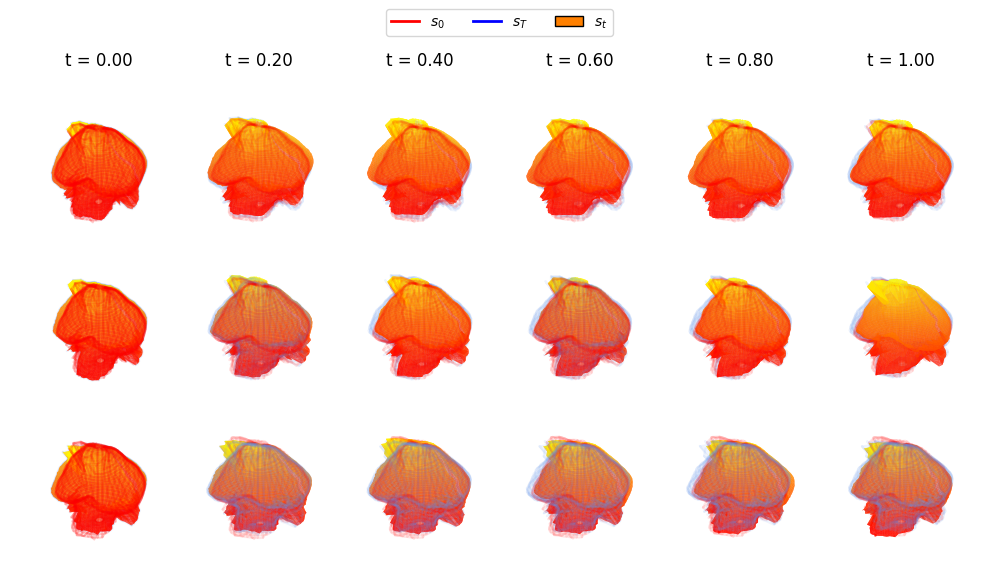

In [9]:
x0s = jnp.stack([x0[0], x0[0], x0[0]], axis=0)
xTs = jnp.stack([xT[0], xT_lepus_saxa[0], xT_lepus_californicus[0]], axis=0)
condition_xs = jnp.stack([conditioned_xs_lepus, conditioned_xs_lepus_saxa, conditioned_xs_lepus_californicus], axis=0)
plot_time_slice_shape(x0s, xTs, condition_xs)

In [10]:


xs_score = jax.vmap(score_fn, in_axes=(0, 0, None))(xs[:-1], time_lst, x0[0])

In [11]:
# plot score field on the sphere, show quiver plot
def plot_score_field_on_sphere(score_field, x, title=None, savefig = False):
    # plot the score field on the sphere
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.set_axis_off()
    ax.grid(False)
    ax.elev = 20
    ax.azim = -60
    # ax.scatter(x[:,:, 0], x[:,:, 1], x[:,:, 2], alpha=1.0, color="yellow",zorder=12, marker="+",s= 50)
    ax.scatter(x[:,:, 0], x[:,:, 1], x[:,:, 2], alpha=0.5, color="red",zorder=10)
    ax.quiver(x[:, :, 0], x[:, :, 1], x[:, :, 2], score_field[:, :, 0], score_field[:, :, 1], score_field[:, :, 2],
              alpha=0.5, color="blue",zorder=10, length=0.4)
    plt.tight_layout()
    if savefig:
        plt.savefig(f"score_field_on_sphere_{title}.png", dpi=300,transparent=True,bbox_inches="tight")

def plot_sphere(x, title= None, savefig = False):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.set_axis_off()
    ax.grid(False)
    ax.elev = 20
    ax.azim = -60
    # set
    ax.scatter(x[:,:, 0], x[:,:, 1], x[:,:, 2], alpha=0.5, color="red",zorder=11)
    plt.tight_layout()
    if savefig and title is not None:
        plt.savefig(f"sphere_{title}.png", dpi=300,transparent=True,bbox_inches="tight")

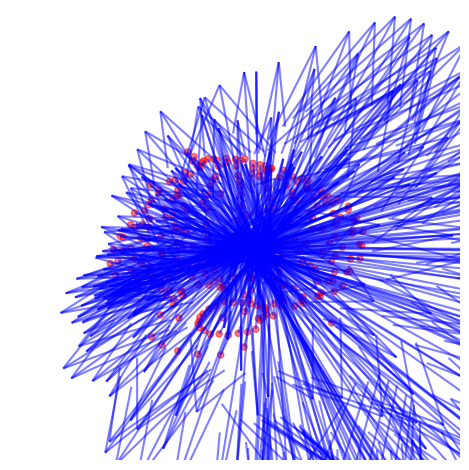

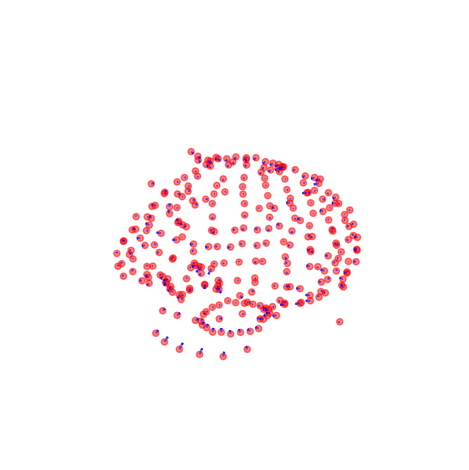

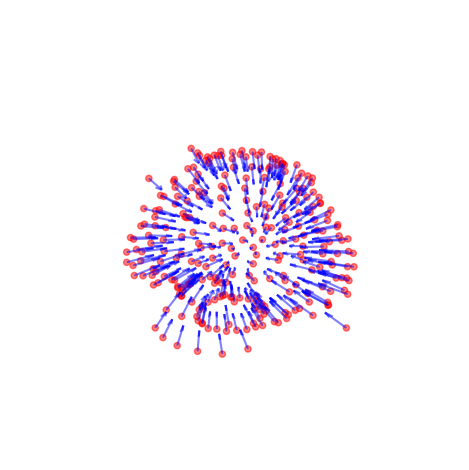

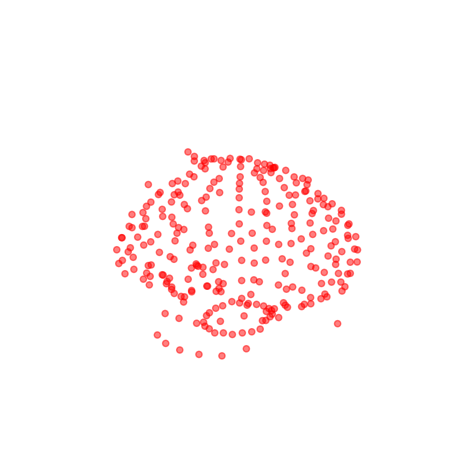

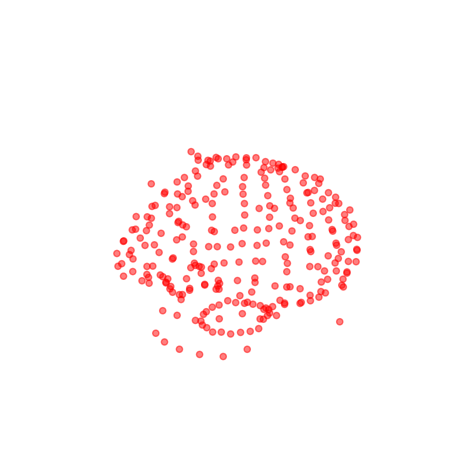

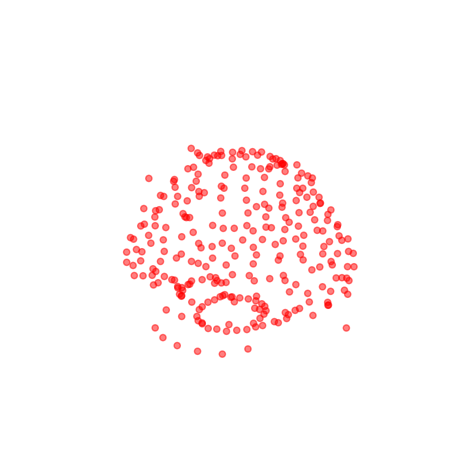

In [12]:
plot_score_field_on_sphere(xs_score[4], xs[4])
plot_score_field_on_sphere(xs_score[22], xs[22])
plot_score_field_on_sphere(xs_score[49], xs[45])


plot_sphere(xs[14])
plot_sphere(xs[22])
plot_sphere(xs[45])